# 📊 Material Aging — Week-over-Week Comparative Analysis

**Author:** Jose Alberto  
**Date:** March 2026  
**Depends on:** `material_aging_raw.csv`

---

## 🎯 Business Context

A single aging snapshot tells us where we are. A **week-over-week comparison** tells us whether we are moving in the right direction.

This notebook automates what was previously done manually in Excel — pivoting two reports and comparing them side by side — and adds a layer of analysis that Excel cannot easily provide: **which materials migrated between aging bands** and what that means for the business.

### 🔍 Questions we want to answer
1. Did total at-risk inventory grow or shrink vs. last week?
2. Which aging bands are gaining or losing value?
3. Which materials **worsened** (moved to a higher-risk band)?
4. Which materials **improved** (consumed or moved to a lower band)?
5. What is the net weekly aging movement in dollar terms?

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ── Styling ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

BAND_COLORS = {
    '0-30':   '#2ecc71',
    '31-60':  '#f1c40f',
    '61-90':  '#e67e22',
    '91-120': '#e74c3c',
    '121+':   '#7f0000',
}
BAND_ORDER = ['0-30', '31-60', '61-90', '91-120', '121+']

# ── Reference dates ───────────────────────────────────
DATE_CURRENT = pd.Timestamp('2026-03-13')   # Current week snapshot
DATE_PREVIOUS = pd.Timestamp('2026-03-06')  # Previous week snapshot

# ── Load raw data ─────────────────────────────────────
BASE = Path(r"C:\Users\Beto\Portafolio Beto\Aging")
df_raw = pd.read_csv(BASE / "Data" / "material_aging_raw.csv", parse_dates=['Input Date'])

print(f"✅ Raw dataset loaded: {df_raw.shape[0]:,} records")
print(f"   Current week  : {DATE_CURRENT.date()}")
print(f"   Previous week : {DATE_PREVIOUS.date()}")

✅ Raw dataset loaded: 333 records
   Current week  : 2026-03-13
   Previous week : 2026-03-06


---
## 2. Build Weekly Snapshots

We simulate two weekly snapshots by calculating aging bands relative to each reference date.
In a real SAP environment, these would be two separate extracts from the development Z-report,
one pulled each Friday.

In [2]:
def assign_aging_band(days):
    """Classify days in stock into aging band."""
    if days <= 30:    return '0-30'
    elif days <= 60:  return '31-60'
    elif days <= 90:  return '61-90'
    elif days <= 120: return '91-120'
    else:             return '121+'

def build_snapshot(df, reference_date, label):
    """Build an aggregated aging snapshot for a given reference date."""
    snap = df.copy()
    snap['Days in Stock'] = (reference_date - snap['Input Date']).dt.days
    snap['Aging Band'] = snap['Days in Stock'].apply(assign_aging_band)
    snap['Aging Band'] = pd.Categorical(snap['Aging Band'], categories=BAND_ORDER, ordered=True)
    snap['Week'] = label
    return snap

df_current  = build_snapshot(df_raw, DATE_CURRENT,  'Current Week')
df_previous = build_snapshot(df_raw, DATE_PREVIOUS, 'Previous Week')

GROUP_KEYS = ['Material Code', 'Material Desc', 'Product Type', 'Material Type', 'UoM']

def aggregate_snapshot(df):
    """Aggregate by material and aging band."""
    return (
        df.groupby(GROUP_KEYS + ['Aging Band'], observed=True)
        .agg(Qty=('Qty','sum'), Amt=('Amt','sum'))
        .reset_index()
    )

snap_curr = aggregate_snapshot(df_current)
snap_prev = aggregate_snapshot(df_previous)

print(f"✅ Snapshots built:")
print(f"   Current week  : {snap_curr.shape[0]:,} records")
print(f"   Previous week : {snap_prev.shape[0]:,} records")

✅ Snapshots built:
   Current week  : 274 records
   Previous week : 260 records


---
## 3. Band-Level Comparison

First we look at the **macro movement** — did each aging band grow or shrink in total value?

In [3]:
def band_totals(snap, week_label):
    return (
        snap.groupby('Aging Band', observed=True)['Amt']
        .sum()
        .reindex(BAND_ORDER)
        .fillna(0)
        .rename(week_label)
    )

curr_totals = band_totals(snap_curr, 'Current Week')
prev_totals = band_totals(snap_prev, 'Previous Week')

comparison = pd.DataFrame({'Previous Week': prev_totals, 'Current Week': curr_totals})
comparison['Delta Amt']  = comparison['Current Week'] - comparison['Previous Week']
comparison['Delta %']    = (comparison['Delta Amt'] / comparison['Previous Week'] * 100).round(1)
comparison['Direction']  = comparison['Delta Amt'].apply(
    lambda x: '🔴 Worsened' if x > 0 else ('🟢 Improved' if x < 0 else '⚪ No change')
)

# For 0-30, more = improved; for risk bands, more = worsened
comparison.loc['0-30', 'Direction'] = (
    '🟢 Improved' if comparison.loc['0-30', 'Delta Amt'] > 0 else
    '🔴 Worsened' if comparison.loc['0-30', 'Delta Amt'] < 0 else '⚪ No change'
)

print("📊 Week-over-week movement by aging band:\n")
print(f"{'Band':<12} {'Prev Week':>16} {'Curr Week':>16} {'Delta $':>14} {'Delta %':>9} {'':>15}")
print("-" * 85)
for band in BAND_ORDER:
    row = comparison.loc[band]
    print(f"{band:<12} ${row['Previous Week']:>14,.0f} ${row['Current Week']:>14,.0f} "
          f"${row['Delta Amt']:>+12,.0f} {row['Delta %']:>+8.1f}%  {row['Direction']}")
print("-" * 85)

total_risk_prev = prev_totals[['61-90','91-120','121+']].sum()
total_risk_curr = curr_totals[['61-90','91-120','121+']].sum()
delta_risk = total_risk_curr - total_risk_prev
print(f"\n{'🚨 Total at-risk (>60d)':<30} ${total_risk_prev:>14,.0f} ${total_risk_curr:>14,.0f} ${delta_risk:>+12,.0f}")

📊 Week-over-week movement by aging band:

Band                Prev Week        Curr Week        Delta $   Delta %                
-------------------------------------------------------------------------------------
0-30         $   114,555,371 $    91,428,068 $ -23,127,304    -20.2%  🔴 Worsened
31-60        $    80,403,518 $    88,376,742 $  +7,973,224     +9.9%  🔴 Worsened
61-90        $    57,778,353 $    62,072,954 $  +4,294,600     +7.4%  🔴 Worsened
91-120       $    41,703,330 $    46,719,722 $  +5,016,393    +12.0%  🔴 Worsened
121+         $    49,774,336 $    55,617,423 $  +5,843,086    +11.7%  🔴 Worsened
-------------------------------------------------------------------------------------

🚨 Total at-risk (>60d)         $   149,256,019 $   164,410,098 $ +15,154,079


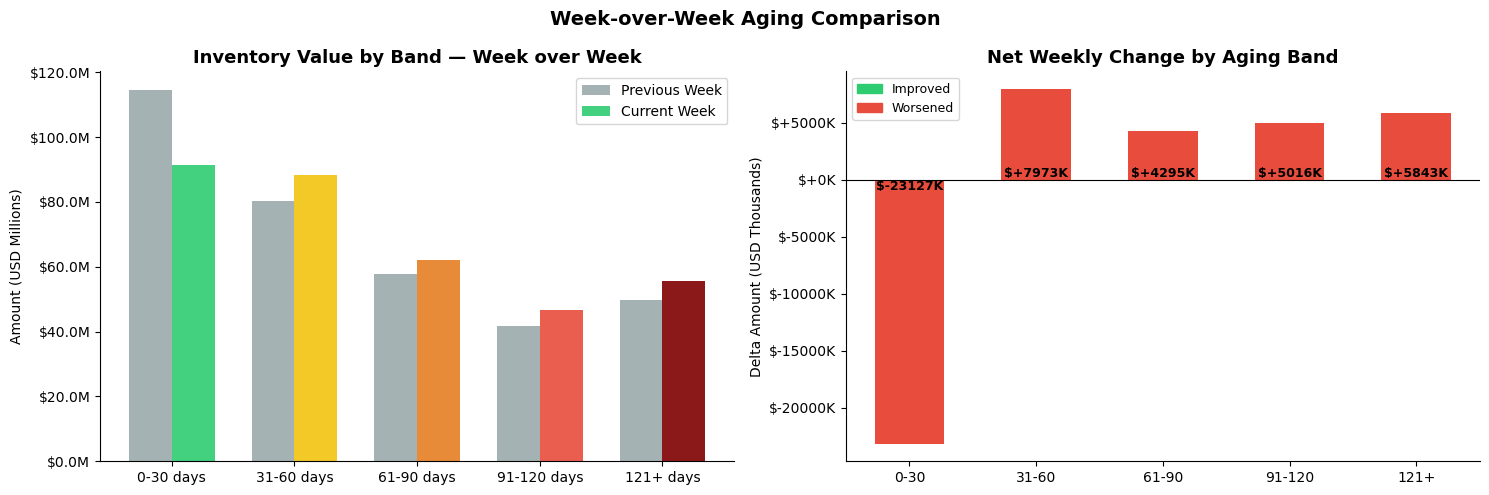

✅ Chart saved.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(BAND_ORDER))
width = 0.35

# ── Grouped bar: Prev vs Curr ────────────────────────
ax1 = axes[0]
bars_prev = ax1.bar(x - width/2, comparison['Previous Week']/1e6, width,
                    label='Previous Week', color='#95a5a6', alpha=0.85)
bars_curr = ax1.bar(x + width/2, comparison['Current Week']/1e6,  width,
                    label='Current Week',  color=[BAND_COLORS[b] for b in BAND_ORDER], alpha=0.9)
ax1.set_xticks(x)
ax1.set_xticklabels([f'{b} days' for b in BAND_ORDER])
ax1.set_title('Inventory Value by Band — Week over Week')
ax1.set_ylabel('Amount (USD Millions)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.1f}M'))
ax1.legend()

# ── Delta bar: net change ────────────────────────────
ax2 = axes[1]
delta_colors = ['#e74c3c' if d > 0 else '#2ecc71' for d in comparison['Delta Amt']]
# Invert color for 0-30 band (more fresh stock = good)
delta_colors[0] = '#2ecc71' if comparison['Delta Amt'].iloc[0] > 0 else '#e74c3c'
bars_d = ax2.bar(BAND_ORDER, comparison['Delta Amt']/1e3, color=delta_colors, width=0.55)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Net Weekly Change by Aging Band')
ax2.set_ylabel('Delta Amount (USD Thousands)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:+.0f}K'))
for bar, val in zip(bars_d, comparison['Delta Amt']):
    va = 'bottom' if val >= 0 else 'top'
    offset = 5 if val >= 0 else -5
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()/1e3 + offset/1e3,
             f'${val/1e3:+.0f}K', ha='center', va=va, fontsize=9, fontweight='bold')

improved = mpatches.Patch(color='#2ecc71', label='Improved')
worsened = mpatches.Patch(color='#e74c3c', label='Worsened')
ax2.legend(handles=[improved, worsened], fontsize=9)

plt.suptitle('Week-over-Week Aging Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / "Outputs" / "06_wow_band_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved.")

---
## 4. Material-Level Migration Analysis

This is the most actionable part of the report: identifying **which specific materials moved to a worse aging band** this week.  
These are the materials that need an immediate disposition decision — they are getting closer to becoming a write-off.

In [13]:
# ── Get dominant band per material per snapshot ───────
def dominant_band(snap):
    """For each material, return the aging band with the highest Amt."""
    return (
        snap.sort_values('Aging Band', ascending=False)   # risk-first
        .groupby(GROUP_KEYS, as_index=False)
        .first()[GROUP_KEYS + ['Aging Band', 'Amt']]
        .rename(columns={'Aging Band': 'Band', 'Amt': 'Amt'})
    )

dom_curr = dominant_band(snap_curr).rename(columns={'Band':'Band_Curr','Amt':'Amt_Curr'})
dom_prev = dominant_band(snap_prev).rename(columns={'Band':'Band_Prev','Amt':'Amt_Prev'})

migration = dom_curr.merge(dom_prev, on=GROUP_KEYS, how='left')

# Encode bands as numeric for comparison
band_rank = {b: i for i, b in enumerate(BAND_ORDER)}
migration['Rank_Curr'] = migration['Band_Curr'].map(band_rank).astype(int)
migration['Rank_Prev'] = migration['Band_Prev'].map(band_rank).astype(int)
migration['Movement']  = migration['Rank_Curr'] - migration['Rank_Prev']

RISK_BANDS = {'61-90', '91-120', '121+'}

def classify_movement(row):
    prev = row['Band_Prev']
    curr = row['Band_Curr']
    if curr in RISK_BANDS and prev not in RISK_BANDS:
        return 'Worsened'       # Entró a zona de riesgo
    elif curr in RISK_BANDS and prev in RISK_BANDS and row['Movement'] > 0:
        return 'Worsened'       # Empeoró dentro de zona de riesgo
    elif prev in RISK_BANDS and curr not in RISK_BANDS:
        return 'Improved'       # Salió de zona de riesgo
    elif curr not in RISK_BANDS and prev not in RISK_BANDS:
        return 'Stable'         # Movimiento fuera de zona de riesgo — no es alarma
    else:
        return 'Stable'

migration['Status'] = migration.apply(classify_movement, axis=1)

print("📋 Migration summary:")
status_counts = migration['Status'].value_counts()
for status, count in status_counts.items():
    icon = '🔴' if status == 'Worsened' else '🟢' if status == 'Improved' else '⚪'
    print(f"   {icon} {status}: {count} materials")

📋 Migration summary:
   ⚪ Stable: 115 materials
   🔴 Worsened: 20 materials


In [14]:
# ── Top worsened materials ────────────────────────────
worsened = (
    migration[migration['Status'] == 'Worsened']
    .sort_values(['Movement','Amt_Curr'], ascending=[False, False])
    .head(20)
    .reset_index(drop=True)
)

print(f"\n🔴 Top 20 materials that WORSENED this week:\n")
print(f"{'Material':<12} {'Description':<28} {'Prev Band':<12} {'Curr Band':<12} {'Curr Amt':>14}")
print("-" * 82)
for _, row in worsened.iterrows():
    print(f"{row['Material Code']:<12} {row['Material Desc'][:27]:<28} "
          f"{row['Band_Prev']:<12} {row['Band_Curr']:<12} ${row['Amt_Curr']:>13,.0f}")


🔴 Top 20 materials that WORSENED this week:

Material     Description                  Prev Band    Curr Band          Curr Amt
----------------------------------------------------------------------------------
PI-00010     Parte Inyectada 00010        91-120       121+         $    3,479,653
PR-00012     Componente para Refrigerado  61-90        91-120       $    2,624,475
PI-00002     Parte Inyectada 00002        31-60        61-90        $    2,493,514
PI-00008     Parte Inyectada 00008        31-60        61-90        $    2,416,673
PL-00008     Componente para Lavadora 00  91-120       121+         $    2,363,434
PR-00013     Componente para Refrigerado  31-60        61-90        $    2,162,098
LV-00015     Lavadora 00015               61-90        91-120       $    1,686,202
LV-00009     Lavadora 00009               61-90        91-120       $    1,354,074
TE-00013     Tarjeta Electronica 00013    31-60        61-90        $    1,349,663
TE-00007     Tarjeta Electronica 00007   

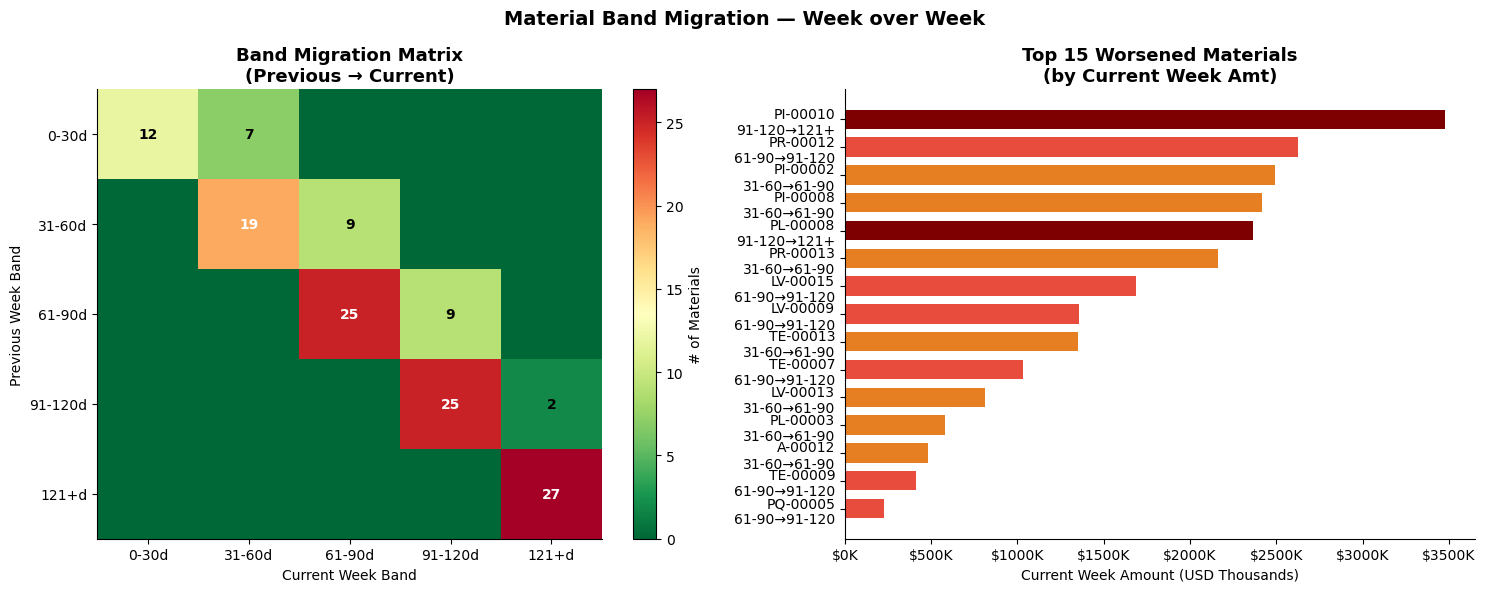

✅ Chart saved.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Sankey-style band migration count ────────────────
ax1 = axes[0]
migration_matrix = (
    migration.groupby(['Band_Prev','Band_Curr'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=BAND_ORDER, columns=BAND_ORDER, fill_value=0)
)
im = ax1.imshow(migration_matrix.values, cmap='RdYlGn_r', aspect='auto')
ax1.set_xticks(range(len(BAND_ORDER)))
ax1.set_yticks(range(len(BAND_ORDER)))
ax1.set_xticklabels([f'{b}d' for b in BAND_ORDER])
ax1.set_yticklabels([f'{b}d' for b in BAND_ORDER])
ax1.set_xlabel('Current Week Band')
ax1.set_ylabel('Previous Week Band')
ax1.set_title('Band Migration Matrix\n(Previous → Current)')
for i in range(len(BAND_ORDER)):
    for j in range(len(BAND_ORDER)):
        val = migration_matrix.values[i, j]
        if val > 0:
            ax1.text(j, i, str(val), ha='center', va='center',
                     fontsize=10, fontweight='bold',
                     color='white' if val > migration_matrix.values.max()*0.5 else 'black')
plt.colorbar(im, ax=ax1, label='# of Materials')

# ── Top 15 worsened materials by Amt ─────────────────
ax2 = axes[1]
top_w = worsened.head(15)
label = top_w['Material Code'] + '\n' + top_w['Band_Prev'].astype(str) + '→' + top_w['Band_Curr'].astype(str)
bar_c = [BAND_COLORS[b] for b in top_w['Band_Curr']]
ax2.barh(label, top_w['Amt_Curr']/1e3, color=bar_c, height=0.7)
ax2.set_title('Top 15 Worsened Materials\n(by Current Week Amt)')
ax2.set_xlabel('Current Week Amount (USD Thousands)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}K'))
ax2.invert_yaxis()

plt.suptitle('Material Band Migration — Week over Week', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / "Outputs" / "07_migration_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved.")

---
## 5. Movement by Material Type & Product Type

After identifying individual material movements, we zoom out to see which **categories** are driving the overall trend.

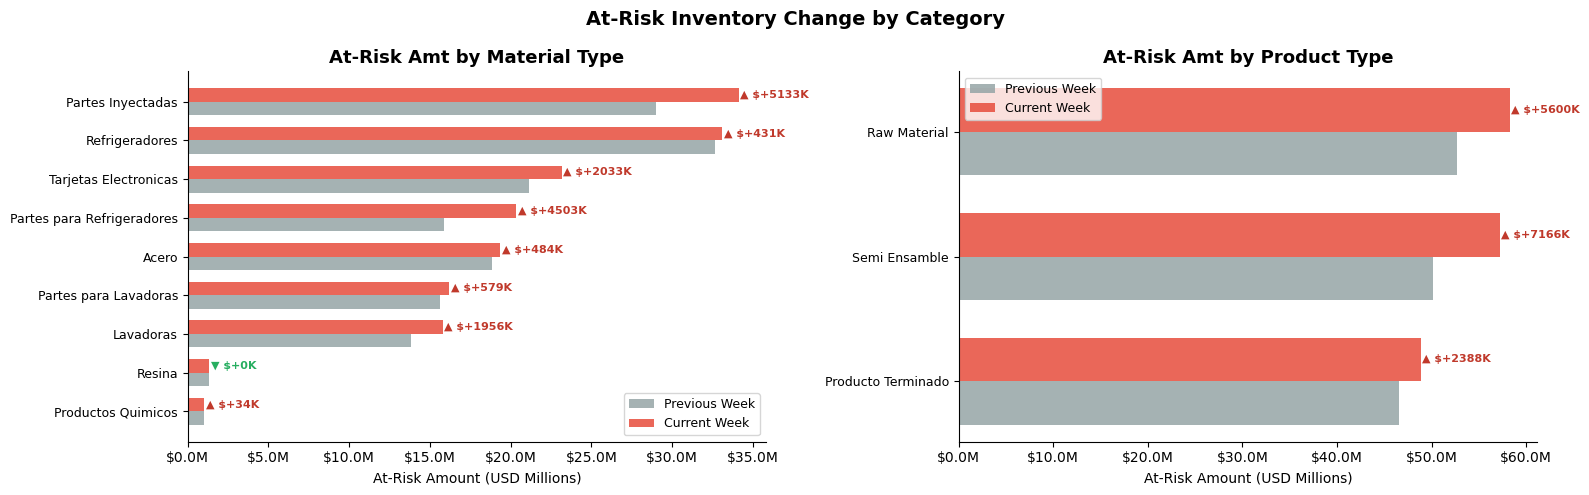

✅ Chart saved.


In [16]:
def risk_by_category(snap, col):
    """Calculate at-risk amount (>60d) grouped by a category column."""
    at_risk = snap[snap['Aging Band'].isin(['61-90','91-120','121+'])]
    return at_risk.groupby(col, observed=True)['Amt'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, title in [
    (axes[0], 'Material Type',  'At-Risk Amt by Material Type'),
    (axes[1], 'Product Type',   'At-Risk Amt by Product Type'),
]:
    risk_prev = risk_by_category(snap_prev, col)
    risk_curr = risk_by_category(snap_curr, col)
    combined  = pd.DataFrame({'Previous': risk_prev, 'Current': risk_curr}).fillna(0)
    combined['Delta'] = combined['Current'] - combined['Previous']
    combined = combined.sort_values('Current', ascending=True)

    x = np.arange(len(combined))
    w = 0.35
    ax.barh(x - w/2, combined['Previous']/1e6, w, label='Previous Week', color='#95a5a6', alpha=0.85)
    ax.barh(x + w/2, combined['Current']/1e6,  w, label='Current Week',  color='#e74c3c', alpha=0.85)

    for i, (_, row) in enumerate(combined.iterrows()):
        delta = row['Delta']
        icon  = '▲' if delta > 0 else '▼'
        color = '#c0392b' if delta > 0 else '#27ae60'
        ax.text(row['Current']/1e6 + 0.1, i + w/2,
                f"{icon} ${delta/1e3:+.0f}K", va='center', fontsize=8,
                fontweight='bold', color=color)

    ax.set_yticks(x)
    ax.set_yticklabels(combined.index, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel('At-Risk Amount (USD Millions)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.1f}M'))
    ax.legend(fontsize=9)

plt.suptitle('At-Risk Inventory Change by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / "Outputs" / "08_category_movement.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved.")

---
## 6. Weekly Executive Summary Table

This is the output that replaces the manual Excel report — a clean, auto-generated table
that can be exported and sent directly to management every Friday.

In [18]:
# ── Build full pivot for both weeks ──────────────────
def build_pivot(snap):
    piv = (
        snap.pivot_table(index=GROUP_KEYS, columns='Aging Band',
                         values='Amt', aggfunc='sum', observed=True)
        .fillna(0)
        .reindex(columns=BAND_ORDER, fill_value=0)
    )
    piv['Total'] = piv.sum(axis=1)
    piv['At Risk >60d'] = piv[['61-90','91-120','121+']].sum(axis=1)
    return piv

piv_curr = build_pivot(snap_curr).add_suffix(' (Curr)')
piv_prev = build_pivot(snap_prev).add_suffix(' (Prev)')

exec_report = piv_curr.join(piv_prev)
exec_report['Delta At Risk'] = exec_report['At Risk >60d (Curr)'] - exec_report['At Risk >60d (Prev)']
exec_report['Delta %'] = np.where(
    exec_report['At Risk >60d (Prev)'] == 0,
    np.nan,
    (exec_report['Delta At Risk'] / exec_report['At Risk >60d (Prev)'] * 100).round(1)
)
exec_report['Alert']         = exec_report['Delta At Risk'].apply(
    lambda x: '🔴 URGENT' if x > 50000 else ('⚠️ WATCH' if x > 0 else '✅ OK')
)

exec_report['Band_Worsened'] = migration.set_index(GROUP_KEYS)['Status'].reindex(exec_report.index).fillna('Stable')

exec_report['Alert'] = np.where(
    exec_report['Delta At Risk'] > 50000,  '🔴 URGENT',
np.where(
    exec_report['Band_Worsened'] == 'Worsened', '⚠️ WATCH',
np.where(
    exec_report['Delta At Risk'] > 0,      '⚠️ WATCH',
                                           '✅ OK'
)))
# Export to Excel
output_cols = [
    '0-30 (Curr)', '31-60 (Curr)', '61-90 (Curr)', '91-120 (Curr)', '121+ (Curr)',
    'Total (Curr)', 'At Risk >60d (Curr)', 'At Risk >60d (Prev)', 'Delta At Risk', 'Delta %', 'Alert'
]

export_df = exec_report[output_cols].reset_index()
export_path = BASE / "Outputs" / "weekly_aging_report.xlsx"
export_df.to_excel(export_path, index=False)

print(f"✅ Weekly report exported to: {export_path}")
print(f"\n📋 Report preview — materials with URGENT alert:")
urgent = export_df[export_df['Alert'] == '🔴 URGENT'].sort_values('Delta At Risk', ascending=False).head(10)
if len(urgent) > 0:
    print(urgent[['Material Code','Material Desc','At Risk >60d (Curr)','Delta At Risk','Delta %']]
          .to_string(index=False))
else:
    print("   No urgent materials this week — good news!")

✅ Weekly report exported to: C:\Users\Beto\Portafolio Beto\Aging\Outputs\weekly_aging_report.xlsx

📋 Report preview — materials with URGENT alert:
Material Code                      Material Desc  At Risk >60d (Curr)  Delta At Risk  Delta %
     PI-00002              Parte Inyectada 00002           2493513.55     2493513.55      NaN
     PI-00008              Parte Inyectada 00008           2416673.15     2416673.15      NaN
     PR-00005 Componente para Refrigerador 00005           5139088.14     2341102.76     83.7
     PR-00013 Componente para Refrigerador 00013           2162098.32     2162098.32      NaN
     TE-00013          Tarjeta Electronica 00013           1349663.40     1349663.40      NaN
     LV-00009                     Lavadora 00009           2495754.18     1141680.42     84.3
     LV-00013                     Lavadora 00013            814787.88      814787.88      NaN
     TE-00008          Tarjeta Electronica 00008           2591186.52      683008.32     35.8
     PL

---
## 7. Key Findings & Recommendations

### 📊 Weekly Movement Summary

| Metric | Previous Week | Current Week | Delta |
|---|---|---|---|
| Materials worsened | — | 20 | — |
| Materials improved | — | 0 | ⚠️ None |
| Materials stable | — | 115 | — |
| 🔴 URGENT alerts | — | 12 | — |
| ⚠️ WATCH alerts | — | 11 | — |

---

### 🔎 Observations

1. **Zero materials improved this week.**
   Not a single material moved to a safer aging band or was consumed 
   out of the risk zone. This means the inventory problem is not being 
   actively managed — there are no visible procurement adjustments, 
   production pull or disposition decisions taking effect in this period.

2. **Partes Inyectadas is driving the most critical movements.**
   Three of the top 5 worsened materials belong to this category:
   PI-00010 crossed into the 121+ band ($3.4M), PI-00002 and PI-00008 
   just entered the risk zone from 31-60 days ($2.4M and $2.5M 
   respectively). Combined with the findings from Notebook 1, this 
   category shows a consistent and accelerating pattern that requires 
   immediate escalation.

3. **Lavadoras (Finished Goods) show the highest urgency growth.**
   LV-00009 grew 84.3% in at-risk value in a single week as inventory 
   crossed the 60-day threshold. LV-00013 entered the risk zone as a 
   new entry with $814K. This reinforces the demand signal concern 
   identified in Notebook 1 — finished product is being built faster 
   than it is being sold.

4. **RF-00005 is the fastest-deteriorating single material.**
   Refrigerador 00005 grew its at-risk value by 113% week over week — 
   the highest percentage increase among materials with a valid 
   comparison base. At $813K in risk and accelerating, it requires 
   an immediate commercial review.

5. **11 materials on the WATCH list represent the next wave.**
   Materials like PI-00010, PL-00008 and TE-00007 are already deep 
   in the risk zone with no movement. If no action is taken, these 
   will appear as URGENT in the coming weeks.

---

### 💡 Actions for This Week

1. **URGENT — Partes Inyectadas task force**
   With 3 SKUs in the top 5 and a combined at-risk value exceeding 
   $8M, this category cannot be managed through routine review. 
   Recommend a dedicated session with Planning and Operations to 
   cross-reference open production orders against these specific 
   materials and define a consumption or disposition timeline.

2. **URGENT — Lavadoras commercial alignment**
   LV-00009 and LV-00013 together represent over $3.3M in at-risk 
   finished goods. Share the aging data with the commercial team and 
   request a 30-day sell-through plan. If demand is not there, 
   a production stop on Lavadoras should be evaluated before more 
   Raw Material is converted.

3. **CRITICAL signal — Zero improvements**
   The absence of any improvement this week should be formally 
   communicated to management. It indicates that either no disposition 
   decisions were executed from last week's report, or the report 
   itself is not being acted upon. The value of this analysis depends 
   entirely on the actions it triggers.

4. **WATCH list review**
   Schedule a 30-minute weekly review of the 11 WATCH materials with 
   the planning team. The goal is to confirm that each one has an 
   active consumption plan before it migrates to URGENT status.